<a href="https://colab.research.google.com/github/m-ony/mineria-de-datos/blob/main/Humano_o_IA_parte_2_181619.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Humano o IA parte 2

Monica Hernandez Quiroz - 181619

In [25]:
nltk.download('punkt_tab')
!pip install sentence-splitter

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [30]:
import nltk
from sentence_splitter import SentenceSplitter
import pandas as pd
import numpy as np

In [10]:
ia_text="""Es una herramienta que tiene la capacidad de pensar, actuar, razonar similar a un ser humano.
  La inteligencia artificial se puede usar para distintos ámbitos y ser entrenada para resolver problemas o ayudar a automatizar procesos o actividades diarias dentro de empresas, hogares, instituciones, etc."""

In [11]:
ia2_text="""La Inteligencia Artificial (IA) es un campo de la informática enfocado en el diseño y creación de sistemas, algoritmos y programas capaces de simular procesos cognitivos humanos. Su objetivo principal es permitir que las máquinas analicen datos, identifiquen patrones, razonen lógicamente, tomen decisiones autónomas y aprendan de sus propias experiencias para resolver problemas complejos, abarcando capacidades que van desde la percepción visual y la comprensión del lenguaje natural hasta la automatización adaptativa en diversos entornos."""

In [8]:
#Tokenizador
def tokenizar(libro):
    puntuacion = r'!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~¿¡—–'

    # Normalizar
    libro = libro.lower()

    # Tokenizar
    tokens = nltk.word_tokenize(libro, "spanish")

    # Quitar puntuación de los extremos
    for i, token in enumerate(tokens):
        tokens[i] = token.strip(puntuacion)

    # Volver a formar texto
    texto = " ".join(tokens)

    # Tokenizar nuevamente
    tokens = nltk.word_tokenize(libro, "spanish")

    return tokens

In [9]:
def segmentar_oraciones_tokens(texto):
    splitter = SentenceSplitter(language = 'es')
    texto = texto.replace('\n', ' ').replace('\r', '')
    oraciones = splitter.split(texto)
    oraciones_tokenizadas = []
    for oracion in oraciones:
        if not oracion: continue
        tokens = tokenizar(oracion)
        oraciones_tokenizadas.append(tokens)
    for i, oracion in enumerate(oraciones_tokenizadas):
        oraciones_tokenizadas [i] = [""] + oracion + [""]
    return oraciones_tokenizadas

In [12]:
#Segmentación de Texto 1
oraciones_segmentadas = segmentar_oraciones_tokens(ia_text)
print(oraciones_segmentadas)

[['', 'es', 'una', 'herramienta', 'que', 'tiene', 'la', 'capacidad', 'de', 'pensar', ',', 'actuar', ',', 'razonar', 'similar', 'a', 'un', 'ser', 'humano', '.', ''], ['', 'la', 'inteligencia', 'artificial', 'se', 'puede', 'usar', 'para', 'distintos', 'ámbitos', 'y', 'ser', 'entrenada', 'para', 'resolver', 'problemas', 'o', 'ayudar', 'a', 'automatizar', 'procesos', 'o', 'actividades', 'diarias', 'dentro', 'de', 'empresas', ',', 'hogares', ',', 'instituciones', ',', 'etc', '.', '']]


In [14]:
#Segamnetación de Texto 2
oraciones_segmentadas2 = segmentar_oraciones_tokens(ia2_text)
print(oraciones_segmentadas2)

[['', 'la', 'inteligencia', 'artificial', '(', 'ia', ')', 'es', 'un', 'campo', 'de', 'la', 'informática', 'enfocado', 'en', 'el', 'diseño', 'y', 'creación', 'de', 'sistemas', ',', 'algoritmos', 'y', 'programas', 'capaces', 'de', 'simular', 'procesos', 'cognitivos', 'humanos', '.', ''], ['', 'su', 'objetivo', 'principal', 'es', 'permitir', 'que', 'las', 'máquinas', 'analicen', 'datos', ',', 'identifiquen', 'patrones', ',', 'razonen', 'lógicamente', ',', 'tomen', 'decisiones', 'autónomas', 'y', 'aprendan', 'de', 'sus', 'propias', 'experiencias', 'para', 'resolver', 'problemas', 'complejos', ',', 'abarcando', 'capacidades', 'que', 'van', 'desde', 'la', 'percepción', 'visual', 'y', 'la', 'comprensión', 'del', 'lenguaje', 'natural', 'hasta', 'la', 'automatización', 'adaptativa', 'en', 'diversos', 'entornos', '.', '']]


In [52]:
#----Numero de oraciones-----
numero_oraciones=len(oraciones_segmentadas)+len(oraciones_segmentadas2)

#---Numero de palabras por oración
palabras1_oracion=[]
palabras2_oracion=[]
for oracion in oraciones_segmentadas:
    palabras1_oracion.append(len(oracion))
for oracion in oraciones_segmentadas2:
    palabras2_oracion.append(len(oracion))

#promedio de palabras por oración
promedio= np.mean(palabras1_oracion)
promedio2= np.mean(palabras2_oracion)

#desviación estándar
desviacion=np.std(palabras1_oracion)
desviacion2=np.std(palabras2_oracion)

In [60]:


print("Análisis de ritmo: texto Humano")
print("---------------------------------------\n")
print("Numero de oraciones: ", (len(oraciones_segmentadas)))
print("Numero de palabra por oración: ", (palabras1_oracion))
print("Promedio de palabras por oración: ", promedio)
print("Variabilidad (Desviación Estándar): ", desviacion)
print("\n---------------------------------------")



Análisis de ritmo: texto Humano
---------------------------------------

Numero de oraciones:  2
Numero de palabra por oración:  [21, 35]
Promedio de palabras por oración:  28.0
Variabilidad (Desviación Estándar):  7.0

---------------------------------------


In [59]:
print("Análisis de ritmo: texto IA")
print("---------------------------------------\n")
print("Numero de oraciones: ", (len(oraciones_segmentadas2)))
print("Numero de palabra por oración: ", (palabras2_oracion))
print("Promedio de palabras por oración: ", promedio2)
print("Variabilidad (Desviación Estándar): ", desviacion2)
print("\n---------------------------------------")

Análisis de ritmo: texto IA
---------------------------------------

Numero de oraciones:  2
Numero de palabra por oración:  [33, 55]
Promedio de palabras por oración:  44.0
Variabilidad (Desviación Estándar):  11.0

---------------------------------------


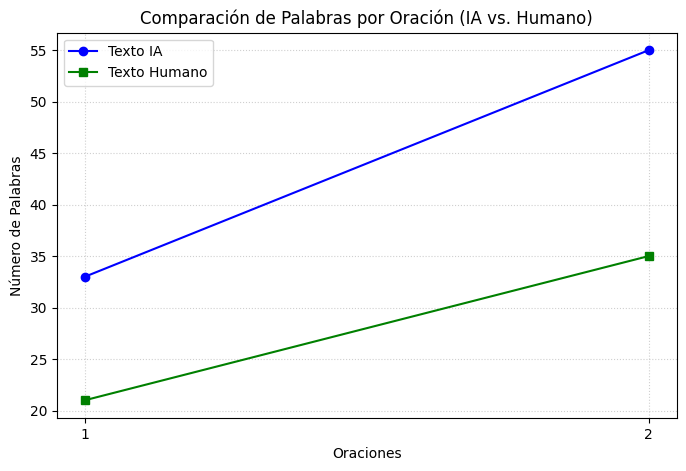

In [56]:
#Gráfica
import matplotlib.pyplot as plt
import numpy as np

palabras_ia = palabras2_oracion
palabras_humano = palabras1_oracion

x = np.arange(1, len(palabras_ia) + 1)

plt.figure(figsize=(8, 5))

plt.plot(x, palabras_ia, label="Texto IA", marker="o", color="blue", linestyle="-")
plt.plot(
    x, palabras_humano, label="Texto Humano", marker="s", color="green", linestyle="-"
)

plt.title("Comparación de Palabras por Oración (IA vs. Humano)")
plt.xlabel("Oraciones")
plt.ylabel("Número de Palabras")

plt.xticks(x)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

